In [2]:
# Gender Bias Regression and Visualization
# ========================================

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.graphics.factorplots import interaction_plot

# Load your dataset
# Replace 'your_dataset.csv' with your actual file name
df = pd.read_csv('salaries_3000.csv')


# Check your data structure
df.head()

# Ensure correct data types
df['gender'] = df['gender'].astype('category')
df['occupation'] = df['occupation'].astype('category')

# Fit OLS regression with interaction terms
model_interaction = smf.ols(
    'middle_salary ~ gender * C(occupation, Treatment(reference=3)) + age', 
    data=df
).fit()
print(model_interaction.summary())


# Display regression results
print(model_interaction.summary())

# Generate predicted salaries
df['predicted_salary'] = model_interaction.predict(df)


                            OLS Regression Results                            
Dep. Variable:          middle_salary   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2810.
Date:                Mon, 16 Jun 2025   Prob (F-statistic):               0.00
Time:                        11:43:43   Log-Likelihood:                -27732.
No. Observations:                3000   AIC:                         5.549e+04
Df Residuals:                    2989   BIC:                         5.555e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [3]:
# Get full p-values from the regression model
pvalues = model_interaction.pvalues

# Create a DataFrame for better readability
results_df = pd.DataFrame({
    'Coefficient': model_interaction.params,
    'P-value': pvalues,
    'Significant (p < 0.05)': pvalues < 0.05
})

# Display all p-values (including reference category)
print(results_df)

                                                     Coefficient  \
Intercept                                           25540.799988   
gender[T.M]                                           -56.203230   
C(occupation, Treatment(reference=3))[T.1]          17258.080726   
C(occupation, Treatment(reference=3))[T.2]           1399.811029   
C(occupation, Treatment(reference=3))[T.4]           1354.419759   
C(occupation, Treatment(reference=3))[T.5]          11191.781581   
gender[T.M]:C(occupation, Treatment(reference=3...   1033.059837   
gender[T.M]:C(occupation, Treatment(reference=3...    720.409300   
gender[T.M]:C(occupation, Treatment(reference=3...    292.906925   
gender[T.M]:C(occupation, Treatment(reference=3...   3553.293445   
age                                                   209.971502   

                                                         P-value  \
Intercept                                           0.000000e+00   
gender[T.M]                                    

In [9]:
# Get coefficients and variable names
coefficients = model_interaction.params
variables = model_interaction.params.index

# Create a DataFrame for clarity
coef_df = pd.DataFrame({
    'Variable': variables,
    'Coefficient': coefficients.round(2)  # Round for readability
})

equation = "middle_salary = "

# Add intercept
intercept = coef_df.loc['Intercept', 'Coefficient']
equation += f"{intercept} "

# Add other terms
for var, coef in zip(variables[1:], coefficients[1:]):  # Skip intercept
    if coef >= 0:
        equation += f"+ {coef:.2f}*{var} "
    else:
        equation += f"- {abs(coef):.2f}*{var} "

print("\nRegression Equation:\n", equation)


Regression Equation:
 middle_salary = 25540.8 - 56.20*gender[T.M] + 17258.08*C(occupation, Treatment(reference=3))[T.1] + 1399.81*C(occupation, Treatment(reference=3))[T.2] + 1354.42*C(occupation, Treatment(reference=3))[T.4] + 11191.78*C(occupation, Treatment(reference=3))[T.5] + 1033.06*gender[T.M]:C(occupation, Treatment(reference=3))[T.1] + 720.41*gender[T.M]:C(occupation, Treatment(reference=3))[T.2] + 292.91*gender[T.M]:C(occupation, Treatment(reference=3))[T.4] + 3553.29*gender[T.M]:C(occupation, Treatment(reference=3))[T.5] + 209.97*age 


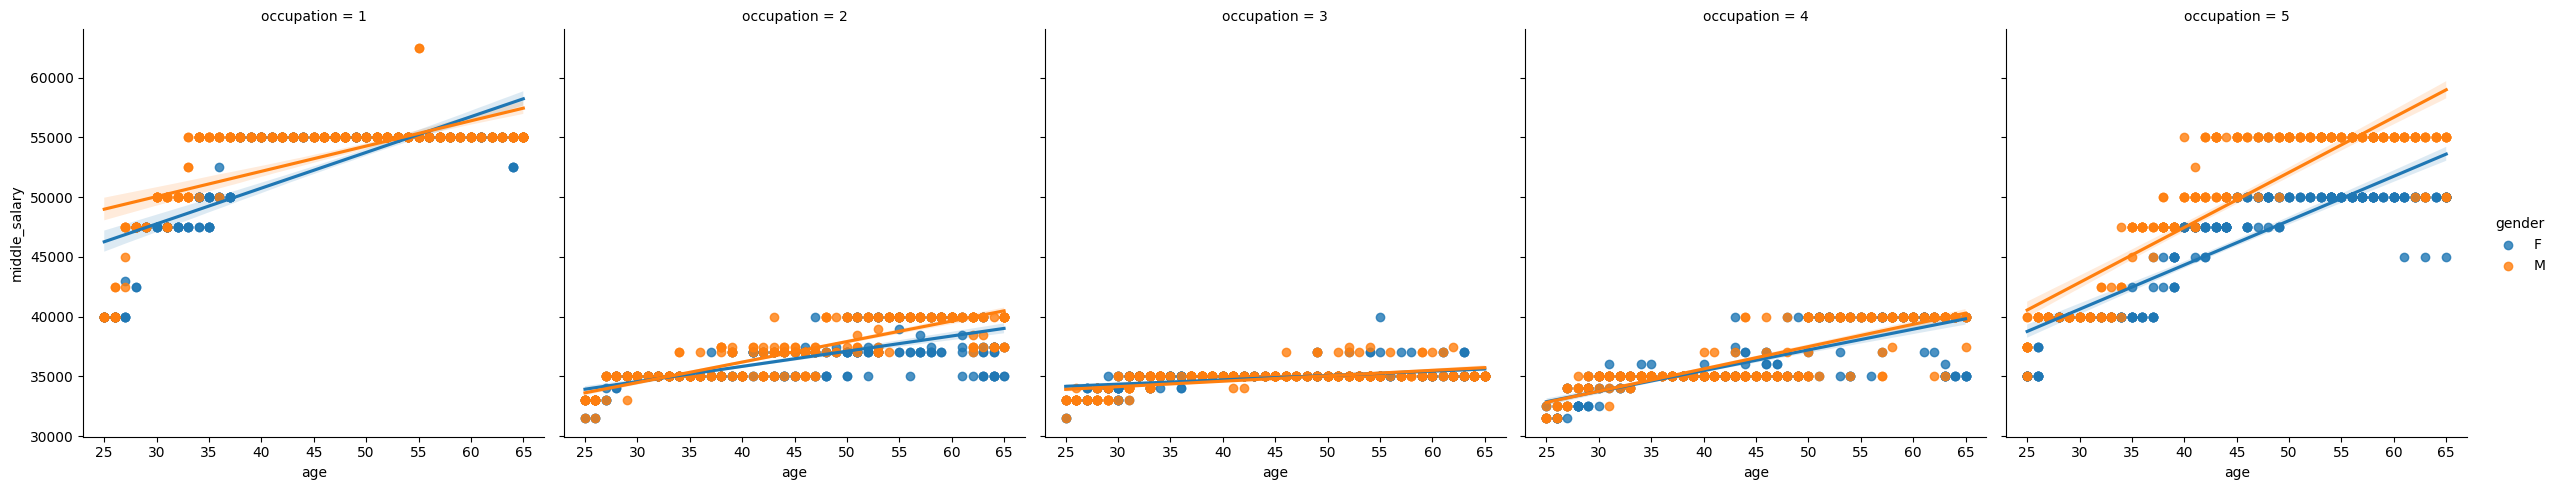

In [10]:
sns.lmplot(x='age', y='middle_salary', hue='gender', col='occupation', data=df)

C:\Users\Bruger\AppData\Local\Temp\ipykernel_10316\1124969645.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x='occupation', y='predicted_salary', hue='gender', ci='sd')


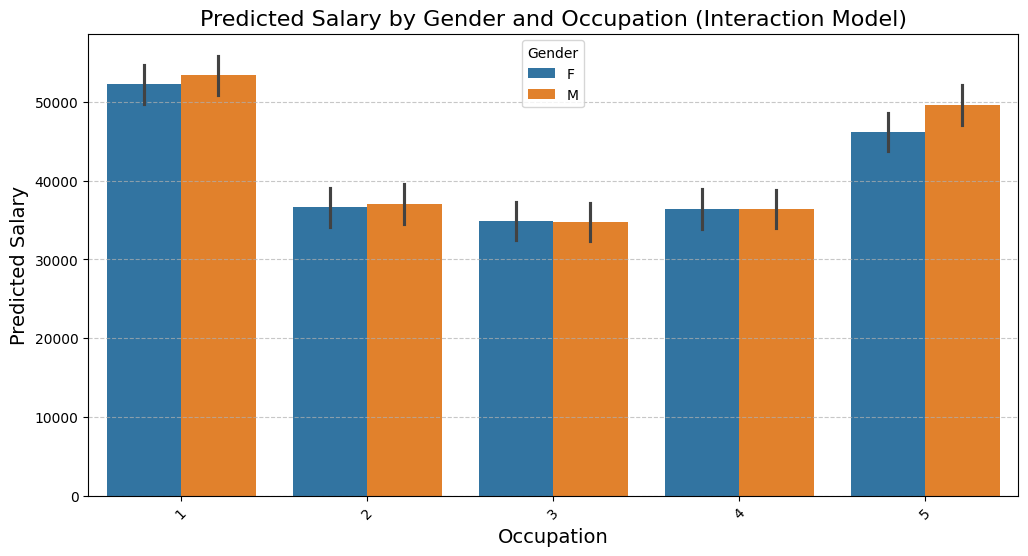

In [4]:
# -----------------------------------
# Visualization 1: Bar Plot
# -----------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='occupation', y='predicted_salary', hue='gender', ci='sd')

plt.title('Predicted Salary by Gender and Occupation (Interaction Model)', fontsize=16)
plt.ylabel('Predicted Salary', fontsize=14)
plt.xlabel('Occupation', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\factorplots.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = data.groupby(['trace', 'x']).aggregate(func).reset_index()
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\factorplots.py:131: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (values, group) in enumerate(plot_data.groupby('trace')):


<Figure size 1000x600 with 0 Axes>

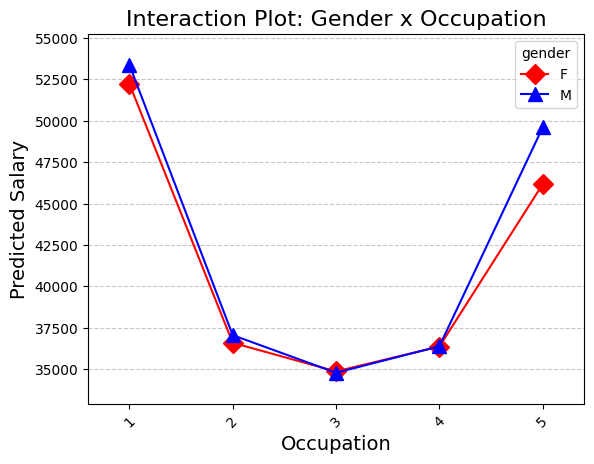

In [5]:
# -----------------------------------
# Visualization 2: Interaction Plot
# -----------------------------------
plt.figure(figsize=(10, 6))
interaction_plot(df['occupation'], df['gender'], df['predicted_salary'],
                 colors=['red', 'blue'], markers=['D', '^'], ms=10)

plt.title('Interaction Plot: Gender x Occupation', fontsize=16)
plt.ylabel('Predicted Salary', fontsize=14)
plt.xlabel('Occupation', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


C:\Users\Bruger\AppData\Local\Temp\ipykernel_10316\1988696677.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=coef_df, y='Variable', x='Coef.', join=False)


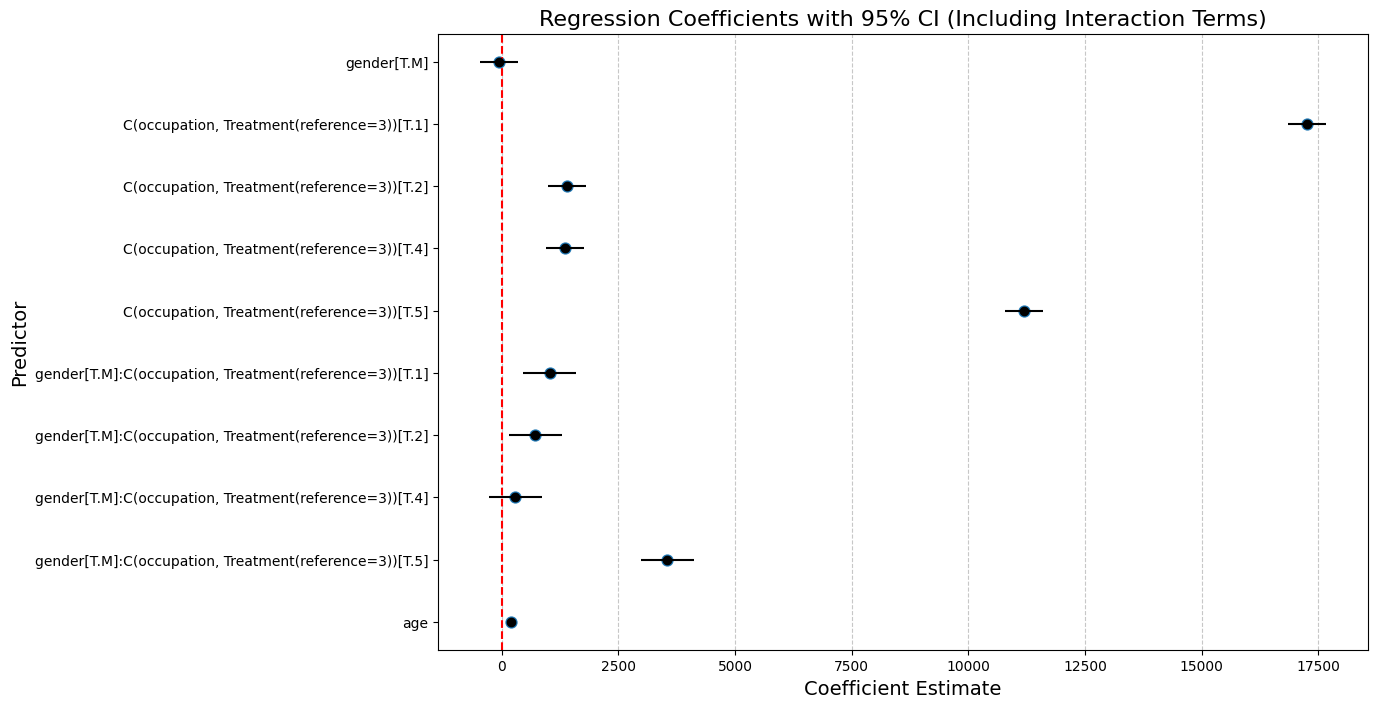

In [6]:
# -----------------------------------
# Visualization 3: Coefficient Plot
# -----------------------------------
# Extract coefficients and confidence intervals
summary_frame = model_interaction.summary2().tables[1].reset_index()
summary_frame = summary_frame.rename(columns={'index': 'Variable'})

# Exclude intercept
coef_df = summary_frame[summary_frame['Variable'] != 'Intercept']

plt.figure(figsize=(12, 8))
sns.pointplot(data=coef_df, y='Variable', x='Coef.', join=False)
plt.errorbar(coef_df['Coef.'], coef_df['Variable'], 
             xerr=(coef_df['[0.025'] - coef_df['Coef.']).abs(), 
             fmt='o', color='black')

plt.axvline(x=0, color='red', linestyle='--')
plt.title('Regression Coefficients with 95% CI (Including Interaction Terms)', fontsize=16)
plt.xlabel('Coefficient Estimate', fontsize=14)
plt.ylabel('Predictor', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [7]:
gap_by_occupation = df.groupby(['occupation', 'gender'])['middle_salary'].mean().unstack()
gap_by_occupation['gap'] = gap_by_occupation['F'] - gap_by_occupation['M']
print(gap_by_occupation[['M', 'F', 'gap']].sort_values('gap', key=abs))

gender                 M             F          gap
occupation                                         
4           36391.666667  36373.333333   -18.333333
3           34793.333333  34873.333333    80.000000
2           37063.333333  36600.000000  -463.333333
1           53383.333333  52235.000000 -1148.333333
5           49600.000000  46175.000000 -3425.000000


C:\Users\Bruger\AppData\Local\Temp\ipykernel_10316\802639282.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gap_by_occupation = df.groupby(['occupation', 'gender'])['middle_salary'].mean().unstack()
